# Ensemble

Autor: Rafał Bąlicki


## Zadanie 1: Salud 2030

Na potrzeby zadania potraktuj dane jako w pełni zebrane od ankietowanych.

### Wprowadzenie

Pracujesz jako Senior Data Scientist w **Secretaría de Salud de México** – meksykańskim Ministerstwie Zdrowia. Rząd Meksyku przeznaczył ogromne fundusze, angażując Cię do pomocy w wywiązaniu się z globalnych zobowiązań wobec ONZ i WHO.

Meksyk, jako sygnatariusz Agendy 2030, kładzie szczególny nacisk na **3. Cel Zrównoważonego Rozwoju (SDG 3): Dobre zdrowie i jakość życia**. Kluczowym elementem tego celu jest **Zadanie 3.4**, które zakłada ograniczenie do 2030 roku o jedną trzecią przedwczesnej umieralności z powodu chorób niezakaźnych (NCDs) poprzez zapobieganie i leczenie.

Jak jednak spełnić to wymaganie? Bierzesz na celownik otyłość – główny czynnik ryzyka wystąpienia chorób układu krążenia, cukrzycy typu 2 i nadciśnienia, które stanowią trzon problemów zdrowotnych wymienionych w SDG 3. Twoim celem jest stworzenie modelu, który na podstawie danych ankietowych zidentyfikuje osoby wymagające interwencji profilaktycznej. Aby pozyskać zbiór danych do uczenia modeli, w wybranych przychodniach przeprowadzono badanie pilotażowe.

Musisz działać precyzyjnie, ponieważ niedokładny model pominie zagrożonych pacjentów, a model zbyt "ciężki" obliczeniowo nie będzie mógł zostać wdrożony w wiejskich przychodniach o ograniczonych zasobach. W Meksyku, gdzie wskaźniki otyłości należą do najwyższych na świecie, Twoja praca nad optymalnym modelem predykcyjnym jest bezpośrednim wkładem w walkę o wydłużenie życia obywateli i redukcję obciążenia systemu ochrony zdrowia.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych dot. otyłości (UCI ID: 544)](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition).
2. **Wyucz modele klasyfikacyjne**. Wykorzystaj bibliotekę `scikit-learn` i zbadaj:

* **Pojedyncze drzewa decyzyjne** i **regresję logistyczną** – jako bazowe modele, łatwe do interpretacji przez lekarza.
* **Bagging:** `BaggingClassifier` z płytkimi drzewami, głębokimi drzewami oraz z regresją logistyczną. Przetestuj wpływ parametrów *n_estimators*, *bootstrap* i *bootstrap_features* na wyniki.
* **Boosting:** `AdaBoost` (przetestuj na płytkich drzewach i regresji logistycznej) oraz `GradientBoosting` (oparty domyślnie na drzewach). Zbadaj relację (trade-off) między parametrami *n_estimators* i *learning_rate*.
* **Stacking & Voting:** skonstruuj kolejny komitet wg własnego uznania (dobierz parametry i modele). Połącz modele o różnej architekturze, by sprawdzić, czy zespół różnych algorytmów daje lepsze efekty niż pojedynczy "ekspert".

3. **Zwaliduj modele** pod kątem wdrożenia krajowego.

* Dobierz miary **skuteczności** modelu adekwatne do problemu.
* Zwróć uwagę na **czas predykcji**.
* Zbadaj **pewność (confidence) modelu**.

4. **Zapisz wnioski dla Ministerstwa Zdrowia.**

Przy realizacji poleceń pamiętaj o charakterze zadania. Który z modeli zarekomendowałbyś do wdrożenia? Czy dokładność modelu jest jedynym wyznacznikiem jego jakości? Czy są modele, których wdrożenie byłoby stratą zasobów publicznych?

In [25]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
    RandomForestClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")


## EDA


Uwaga: zbiór UCI 544 zawiera zarówno pomiary rzeczywiste, jak i syntetyczne.
Zgodnie z poleceniem traktujemy wszystkie rekordy jako dane zebrane w badaniu pilotażowym.

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II



Braki danych
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Duplikaty: 24

Statystyki numeryczne:


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



Statystyki kategoryczne:


,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
count,2111,2111,2111,2111,2111,2111,2111,2111,2111
unique,2,2,2,4,2,2,4,5,7
top,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,1726,1866,1765,2067,2015,1401,1580,351


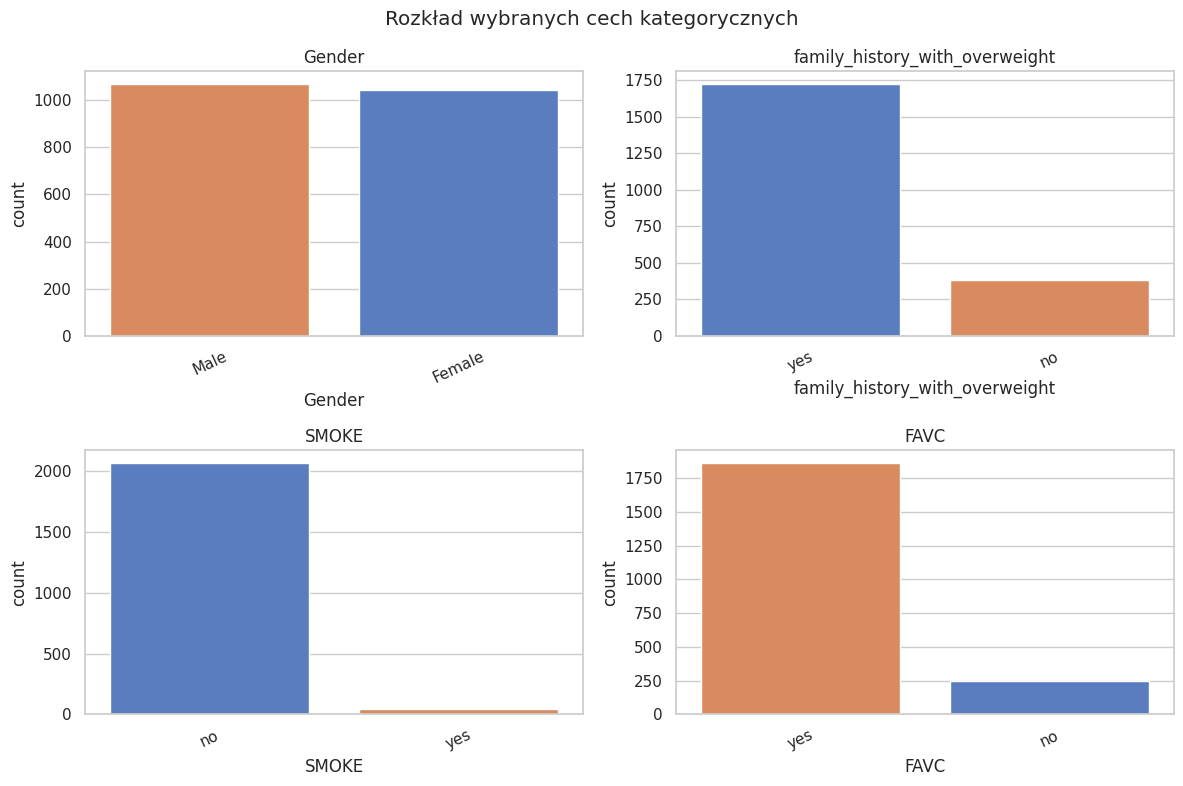

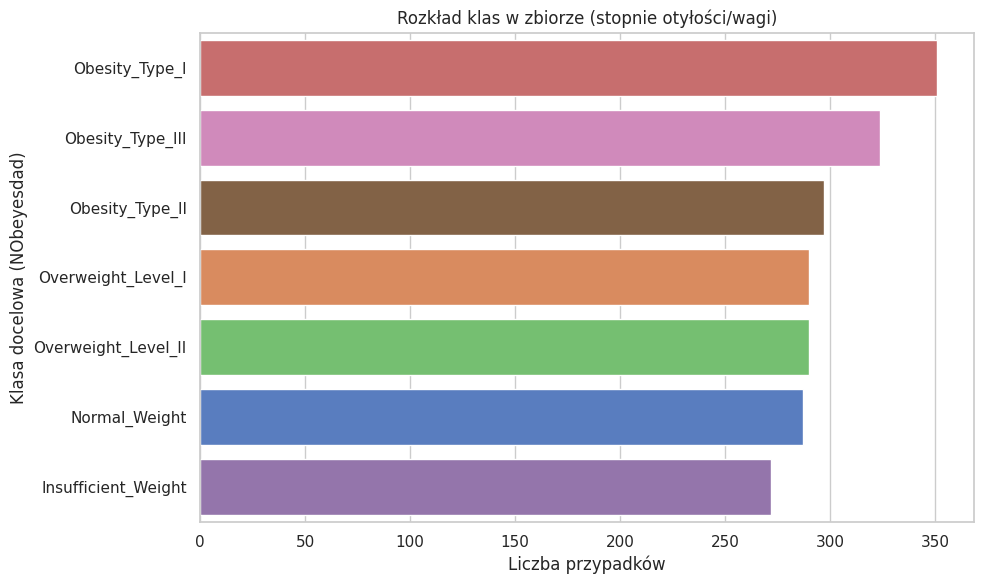

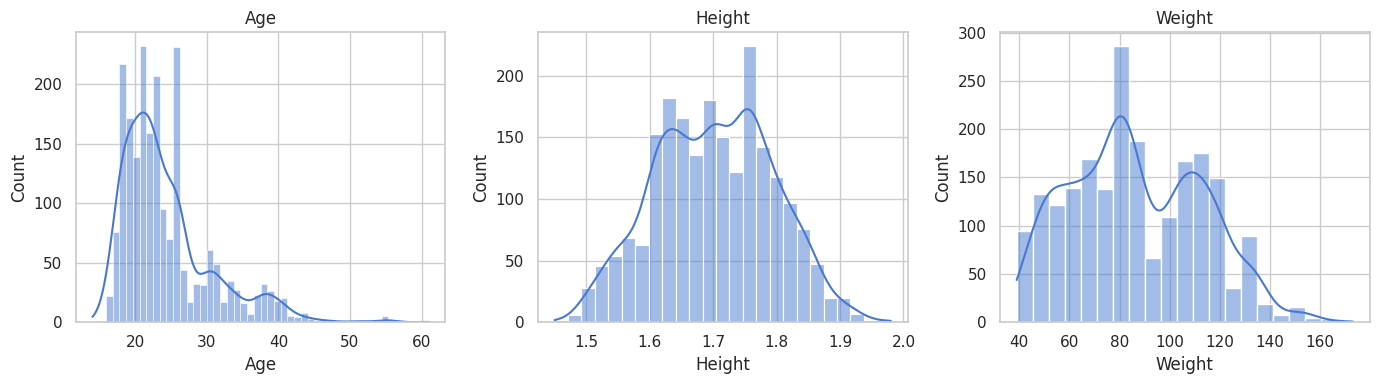

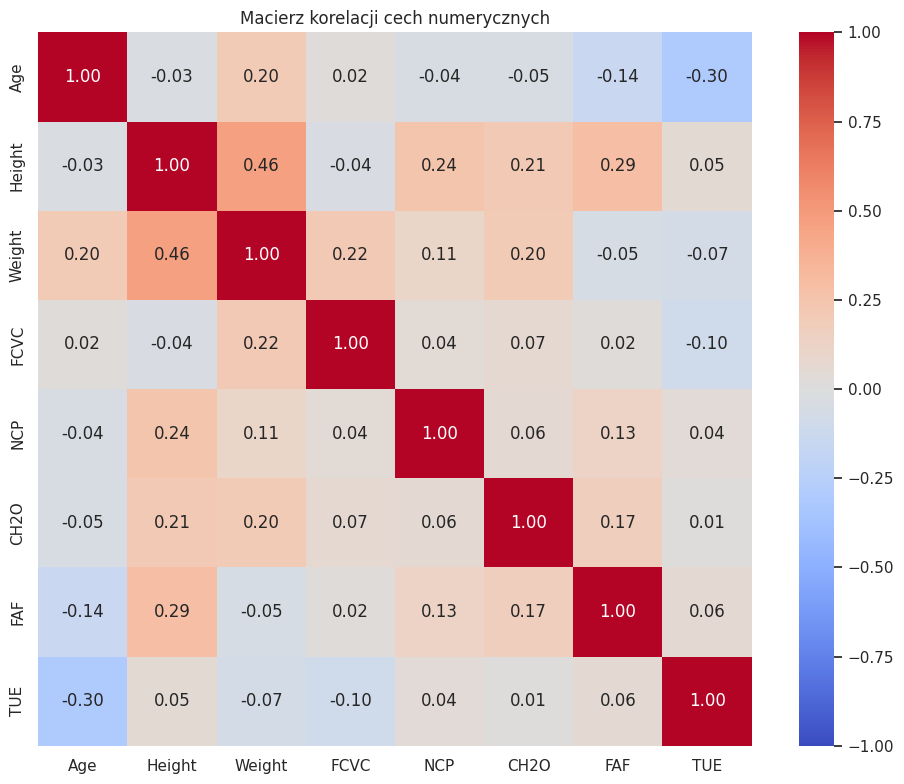

In [26]:
file_path = 'data/meksyk/ObesityDataSet_raw_and_data_sinthetic.csv'
df = pd.read_csv(file_path)

print("Uwaga: zbiór UCI 544 zawiera zarówno pomiary rzeczywiste, jak i syntetyczne.")
print("Zgodnie z poleceniem traktujemy wszystkie rekordy jako dane zebrane w badaniu pilotażowym.\n")

df.info()

print("\nPrzykładowy rekord")
display(df.head())

print("\nBraki danych")
print(df.isnull().sum())

print("\nDuplikaty:", df.duplicated().sum())

print("\nStatystyki numeryczne:")
display(df.describe())

print("\nStatystyki kategoryczne:")
display(df.describe(include='object'))

cat_cols = ['Gender', 'family_history_with_overweight', 'SMOKE', 'FAVC']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, hue=col, legend=False)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=25)
plt.suptitle('Rozkład wybranych cech kategorycznych')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df, y='NObeyesdad',
    order=df['NObeyesdad'].value_counts().index,
    hue='NObeyesdad', legend=False
)
plt.title('Rozkład klas w zbiorze (stopnie otyłości/wagi)')
plt.xlabel('Liczba przypadków')
plt.ylabel('Klasa docelowa (NObeyesdad)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['Age', 'Height', 'Weight']):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, square=True)
plt.title('Macierz korelacji cech numerycznych')
plt.tight_layout()
plt.show()


## Bazowe modele


In [27]:
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

X_encoded = pd.get_dummies(X, drop_first=True)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []

def log_result(name, model, X_te, y_te):
    """Zbiera metryki do tabeli porównawczej i wypisuje skrót wyników."""
    t0 = time.perf_counter()
    y_pred = model.predict(X_te)
    infer_ms = (time.perf_counter() - t0) / len(y_te) * 1000
    y_proba = model.predict_proba(X_te)

    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'F1_macro': f1_score(y_te, y_pred, average='macro'),
        'F1_weighted': f1_score(y_te, y_pred, average='weighted'),
        'Recall_macro': recall_score(y_te, y_pred, average='macro'),
        'Confidence': np.mean(np.max(y_proba, axis=1)),
        'Czas_ms': infer_ms,
    }
    results.append(row)
    print(f"\n{name}")
    print(f"  Accuracy: {row['Accuracy']:.4f} | F1 macro: {row['F1_macro']:.4f} | "
          f"Recall macro: {row['Recall_macro']:.4f} | Czas: {row['Czas_ms']:.4f} ms/próbkę")
    return row


def evaluate_model_detailed(name, model, X_te, y_te):
    """Raport klasyfikacji i macierz pomyłek dla wybranego modelu."""
    y_pred = model.predict(X_te)
    print(f"\n=== {name} (szczegóły) ===")
    print(classification_report(y_te, y_pred, target_names=le.classes_))
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Macierz pomyłek – {name}')
    plt.ylabel('Rzeczywiste')
    plt.xlabel('Predykcja')
    plt.tight_layout()
    plt.show()


tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)
log_result('Drzewo decyzyjne (max_depth=4)', tree_model, X_test, y_test)

log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train_scaled, y_train)
log_result('Regresja logistyczna', log_reg_model, X_test_scaled, y_test)



Drzewo decyzyjne (max_depth=4)
  Accuracy: 0.7541 | F1 macro: 0.7442 | Recall macro: 0.7576 | Czas: 0.0075 ms/próbkę

Regresja logistyczna
  Accuracy: 0.8652 | F1 macro: 0.8580 | Recall macro: 0.8645 | Czas: 0.0015 ms/próbkę


{'Model': 'Regresja logistyczna',
 'Accuracy': 0.8652482269503546,
 'F1_macro': 0.857956272664784,
 'F1_weighted': 0.8625262334050451,
 'Recall_macro': 0.8644725344574382,
 'Confidence': np.float64(0.7645025820643061),
 'Czas_ms': 0.0015372080349580254}

## Bagging


In [28]:
# płtdkie drzewa
for n_est in [10, 50]:
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=4, random_state=42),
        n_estimators=n_est,
        random_state=42,
    )
    bag.fit(X_train, y_train)
    log_result(f'Bagging płytkie drzewa (n={n_est})', bag, X_test, y_test)

# głębokie drzewa (bootstrap)
for bootstrap in [True, False]:
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=None, random_state=42),
        n_estimators=30,
        bootstrap=bootstrap,
        random_state=42,
    )
    bag.fit(X_train, y_train)
    log_result(f'Bagging głębokie drzewa (bootstrap={bootstrap})', bag, X_test, y_test)

# głębokie drzewa (bootstrap_features)
for boot_feat in [False, True]:
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=None, random_state=42),
        n_estimators=30,
        bootstrap=True,
        bootstrap_features=boot_feat,
        max_features=0.7 if boot_feat else 1.0,
        random_state=42,
    )
    bag.fit(X_train, y_train)
    log_result(f'Bagging głębokie (bootstrap_features={boot_feat})', bag, X_test, y_test)

# regresja logistyczna (bootstrap_features)
for boot_feat in [False, True]:
    bag = BaggingClassifier(
        estimator=LogisticRegression(max_iter=1000, random_state=42),
        n_estimators=20,
        bootstrap_features=boot_feat,
        max_features=0.7 if boot_feat else 1.0,
        random_state=42,
    )
    bag.fit(X_train_scaled, y_train)
    log_result(f'Bagging regresja log. (bootstrap_features={boot_feat})', bag, X_test_scaled, y_test)

bag_shallow_10 = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=4, random_state=42),
    n_estimators=10,
    random_state=42,
)
bag_shallow_10.fit(X_train, y_train);



Bagging płytkie drzewa (n=10)
  Accuracy: 0.7825 | F1 macro: 0.7803 | Recall macro: 0.7855 | Czas: 0.0132 ms/próbkę

Bagging płytkie drzewa (n=50)
  Accuracy: 0.7920 | F1 macro: 0.7894 | Recall macro: 0.7948 | Czas: 0.0549 ms/próbkę

Bagging głębokie drzewa (bootstrap=True)
  Accuracy: 0.9504 | F1 macro: 0.9498 | Recall macro: 0.9507 | Czas: 0.0267 ms/próbkę

Bagging głębokie drzewa (bootstrap=False)
  Accuracy: 0.9480 | F1 macro: 0.9476 | Recall macro: 0.9469 | Czas: 0.0263 ms/próbkę

Bagging głębokie (bootstrap_features=False)
  Accuracy: 0.9504 | F1 macro: 0.9498 | Recall macro: 0.9507 | Czas: 0.0233 ms/próbkę

Bagging głębokie (bootstrap_features=True)
  Accuracy: 0.9527 | F1 macro: 0.9522 | Recall macro: 0.9530 | Czas: 0.0379 ms/próbkę

Bagging regresja log. (bootstrap_features=False)
  Accuracy: 0.8558 | F1 macro: 0.8491 | Recall macro: 0.8564 | Czas: 0.0294 ms/próbkę

Bagging regresja log. (bootstrap_features=True)
  Accuracy: 0.8369 | F1 macro: 0.8280 | Recall macro: 0.8352 | 

## Boosting


In [29]:
ada_tree = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42,
)
ada_tree.fit(X_train, y_train)
log_result('AdaBoost płytkie drzewa (n=50, lr=1.0)', ada_tree, X_test, y_test)

ada_tree_slow = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42,
)
ada_tree_slow.fit(X_train, y_train)
log_result('AdaBoost płytkie drzewa (n=100, lr=0.5)', ada_tree_slow, X_test, y_test)

ada_lr = AdaBoostClassifier(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42,
)
ada_lr.fit(X_train_scaled, y_train)
log_result('AdaBoost regresja logistyczna', ada_lr, X_test_scaled, y_test)

gb_fast = GradientBoostingClassifier(n_estimators=50, learning_rate=0.2, random_state=42)
gb_fast.fit(X_train, y_train)
log_result('Gradient Boosting (n=50, lr=0.2)', gb_fast, X_test, y_test)

gb_slow = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
gb_slow.fit(X_train, y_train)
log_result('Gradient Boosting (n=200, lr=0.05)', gb_slow, X_test, y_test)



AdaBoost płytkie drzewa (n=50, lr=1.0)
  Accuracy: 0.5083 | F1 macro: 0.4578 | Recall macro: 0.5145 | Czas: 0.0382 ms/próbkę

AdaBoost płytkie drzewa (n=100, lr=0.5)
  Accuracy: 0.4468 | F1 macro: 0.3893 | Recall macro: 0.4528 | Czas: 0.0758 ms/próbkę

AdaBoost regresja logistyczna
  Accuracy: 0.5981 | F1 macro: 0.6021 | Recall macro: 0.5999 | Czas: 0.0721 ms/próbkę

Gradient Boosting (n=50, lr=0.2)
  Accuracy: 0.9385 | F1 macro: 0.9387 | Recall macro: 0.9411 | Czas: 0.0278 ms/próbkę

Gradient Boosting (n=200, lr=0.05)
  Accuracy: 0.9504 | F1 macro: 0.9501 | Recall macro: 0.9524 | Czas: 0.0667 ms/próbkę


{'Model': 'Gradient Boosting (n=200, lr=0.05)',
 'Accuracy': 0.950354609929078,
 'F1_macro': 0.9500921235914906,
 'F1_weighted': 0.9500474740744073,
 'Recall_macro': 0.9524432606960813,
 'Confidence': np.float64(0.9555789462112534),
 'Czas_ms': 0.06671561937983947}

## Stacking & Voting


In [30]:
clf1_v = DecisionTreeClassifier(max_depth=4, random_state=42)
clf2_v = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
clf3_v = GradientBoostingClassifier(n_estimators=50, learning_rate=0.2, random_state=42)

voting_clf = VotingClassifier(
    estimators=[('dt', clf1_v), ('lr', clf2_v), ('gb', clf3_v)],
    voting='soft',
)
voting_clf.fit(X_train, y_train)
log_result('Voting (Tree + LogReg + GB)', voting_clf, X_test, y_test)

clf1_s = DecisionTreeClassifier(max_depth=4, random_state=42)
clf2_s = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
clf3_s = GradientBoostingClassifier(n_estimators=50, learning_rate=0.2, random_state=42)

stacking_clf = StackingClassifier(
    estimators=[('dt', clf1_s), ('lr', clf2_s), ('gb', clf3_s)],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3,
)
stacking_clf.fit(X_train, y_train)
log_result('Stacking (meta: LogReg)', stacking_clf, X_test, y_test)



Voting (Tree + LogReg + GB)
  Accuracy: 0.9362 | F1 macro: 0.9344 | Recall macro: 0.9359 | Czas: 0.0290 ms/próbkę

Stacking (meta: LogReg)
  Accuracy: 0.9504 | F1 macro: 0.9495 | Recall macro: 0.9513 | Czas: 0.0382 ms/próbkę


{'Model': 'Stacking (meta: LogReg)',
 'Accuracy': 0.950354609929078,
 'F1_macro': 0.9495287774566405,
 'F1_weighted': 0.9501341553812049,
 'Recall_macro': 0.951310345991738,
 'Confidence': np.float64(0.9537240348337583),
 'Czas_ms': 0.03815356973949743}

## Walidacja i porównanie modeli


,Model,Accuracy,F1_macro,F1_weighted,Recall_macro,Confidence,Czas_ms
7,Bagging głębokie (bootstrap_features=True),0.9527,0.9522,0.9527,0.9530,0.7884,0.0379
14,"Gradient Boosting (n=200, lr=0.05)",0.9504,0.9501,0.9500,0.9524,0.9556,0.0667
6,Bagging głębokie (bootstrap_features=False),0.9504,0.9498,0.9502,0.9507,0.9333,0.0233
4,Bagging głębokie drzewa (bootstrap=True),0.9504,0.9498,0.9502,0.9507,0.9333,0.0267
16,Stacking (meta: LogReg),0.9504,0.9495,0.9501,0.9513,0.9537,0.0382
5,Bagging głębokie drzewa (bootstrap=False),0.9480,0.9476,0.9480,0.9469,0.9870,0.0263
13,"Gradient Boosting (n=50, lr=0.2)",0.9385,0.9387,0.9384,0.9411,0.9555,0.0278
15,Voting (Tree + LogReg + GB),0.9362,0.9344,0.9357,0.9359,0.7959,0.0290
1,Regresja logistyczna,0.8652,0.8580,0.8625,0.8645,0.7645,0.0015
8,Bagging regresja log. (bootstrap_features=False),0.8558,0.8491,0.8530,0.8564,0.7598,0.0294


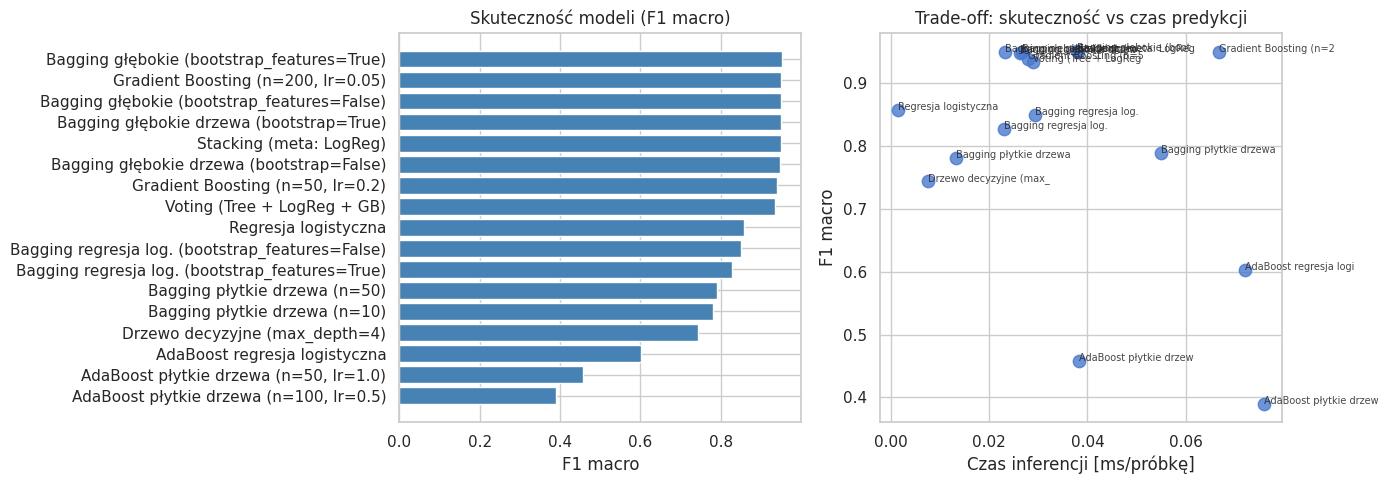


=== Regresja logistyczna (szczegóły) ===
                     precision    recall  f1-score   support

Insufficient_Weight       0.86      1.00      0.93        56
      Normal_Weight       0.89      0.63      0.74        62
     Obesity_Type_I       0.93      0.88      0.91        78
    Obesity_Type_II       0.89      0.97      0.93        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.72      0.73      0.73        56
Overweight_Level_II       0.74      0.84      0.79        50

           accuracy                           0.87       423
          macro avg       0.86      0.86      0.86       423
       weighted avg       0.87      0.87      0.86       423



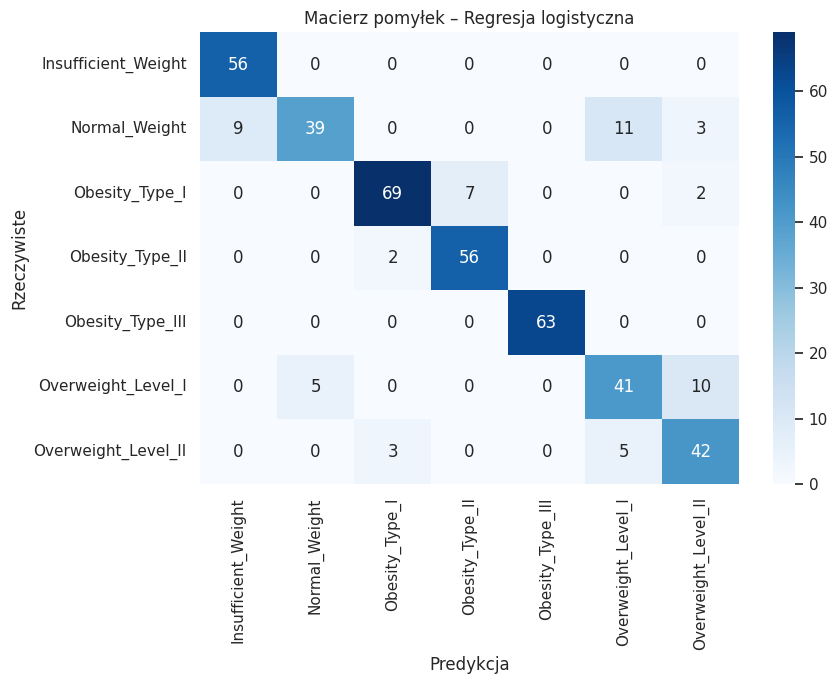


=== Bagging płytkie drzewa (n=10) (szczegóły) ===
                     precision    recall  f1-score   support

Insufficient_Weight       0.85      0.93      0.89        56
      Normal_Weight       0.80      0.65      0.71        62
     Obesity_Type_I       0.84      0.67      0.74        78
    Obesity_Type_II       0.87      0.93      0.90        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.67      0.61      0.64        56
Overweight_Level_II       0.49      0.72      0.58        50

           accuracy                           0.78       423
          macro avg       0.79      0.79      0.78       423
       weighted avg       0.80      0.78      0.78       423



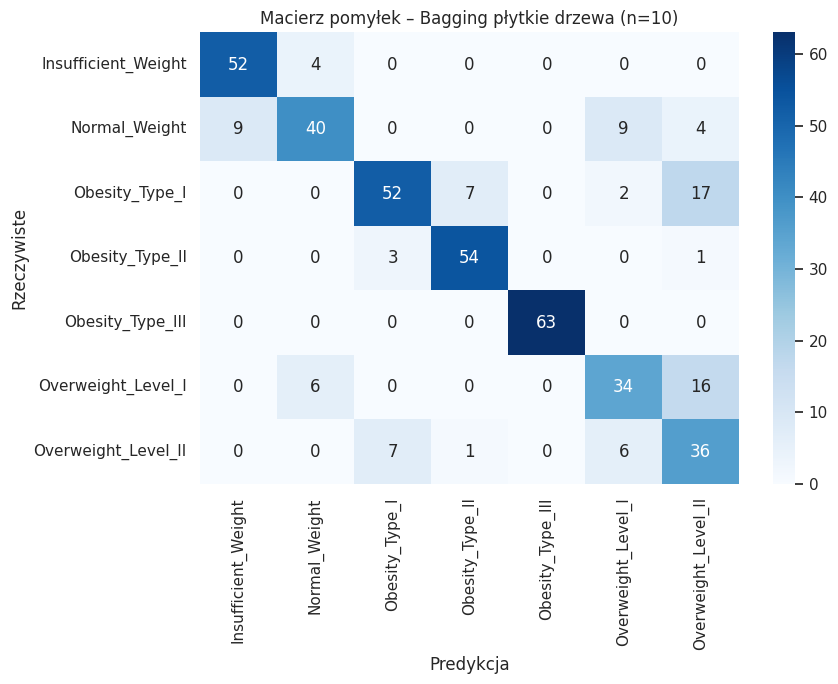


=== Stacking (meta: LogReg) (szczegóły) ===
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.96      0.95        56
      Normal_Weight       0.91      0.85      0.88        62
     Obesity_Type_I       0.99      0.95      0.97        78
    Obesity_Type_II       0.95      0.98      0.97        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.90      0.93      0.91        56
Overweight_Level_II       0.96      0.98      0.97        50

           accuracy                           0.95       423
          macro avg       0.95      0.95      0.95       423
       weighted avg       0.95      0.95      0.95       423



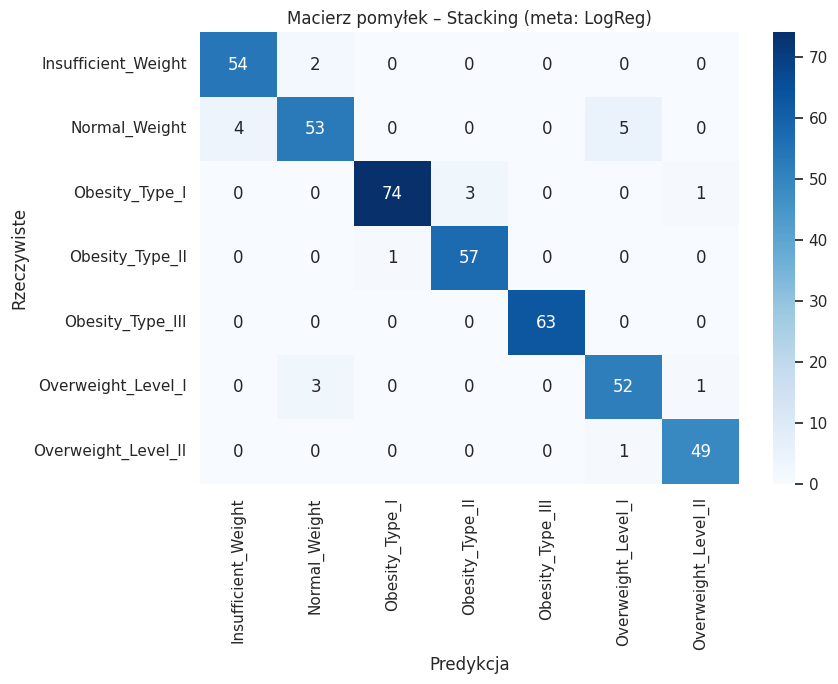


--- Podsumowanie do wniosków ---
Najszybszy model z grupy lekkiej: Bagging głębokie (bootstrap_features=False)
  Accuracy=0.9504, F1 macro=0.9498, Czas=0.0233 ms/próbkę
Najskuteczniejszy (F1 macro): Bagging głębokie (bootstrap_features=True)
  Accuracy=0.9527, F1 macro=0.9522, Czas=0.0379 ms/próbkę
Stosunek czasu (ciężki / lekki): 1.6x


In [31]:
results_df = pd.DataFrame(results).sort_values('F1_macro', ascending=False)
display(results_df.style.format({
    'Accuracy': '{:.4f}',
    'F1_macro': '{:.4f}',
    'F1_weighted': '{:.4f}',
    'Recall_macro': '{:.4f}',
    'Confidence': '{:.4f}',
    'Czas_ms': '{:.4f}',
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = results_df.sort_values('F1_macro', ascending=True)
axes[0].barh(plot_df['Model'], plot_df['F1_macro'], color='steelblue')
axes[0].set_xlabel('F1 macro')
axes[0].set_title('Skuteczność modeli (F1 macro)')

axes[1].scatter(
    results_df['Czas_ms'],
    results_df['F1_macro'],
    s=80,
    alpha=0.8,
)
for _, row in results_df.iterrows():
    axes[1].annotate(
        row['Model'][:22],
        (row['Czas_ms'], row['F1_macro']),
        fontsize=7,
        alpha=0.85,
    )
axes[1].set_xlabel('Czas inferencji [ms/próbkę]')
axes[1].set_ylabel('F1 macro')
axes[1].set_title('Trade-off: skuteczność vs czas predykcji')
plt.tight_layout()
plt.show()

evaluate_model_detailed('Regresja logistyczna', log_reg_model, X_test_scaled, y_test)
evaluate_model_detailed('Bagging płytkie drzewa (n=10)', bag_shallow_10, X_test, y_test)
evaluate_model_detailed('Stacking (meta: LogReg)', stacking_clf, X_test, y_test)

best_fast = results_df.loc[
    results_df['Czas_ms'] <= results_df['Czas_ms'].quantile(0.35)
].iloc[0]
best_heavy = results_df.loc[results_df['F1_macro'].idxmax()]

print("\n--- Podsumowanie do wniosków ---")
print(f"Najszybszy model z grupy lekkiej: {best_fast['Model']}")
print(f"  Accuracy={best_fast['Accuracy']:.4f}, F1 macro={best_fast['F1_macro']:.4f}, "
      f"Czas={best_fast['Czas_ms']:.4f} ms/próbkę")
print(f"Najskuteczniejszy (F1 macro): {best_heavy['Model']}")
print(f"  Accuracy={best_heavy['Accuracy']:.4f}, F1 macro={best_heavy['F1_macro']:.4f}, "
      f"Czas={best_heavy['Czas_ms']:.4f} ms/próbkę")
speedup = best_heavy['Czas_ms'] / best_fast['Czas_ms']
print(f"Stosunek czasu (ciężki / lekki): {speedup:.1f}x")


### 1. Analiza eksploracyjna danych

Zbiór 2111 rekordów, 17 cech, brak braków i duplikatów. Docelowo 7 klas otyłości o zrównoważonym rozkładzie. Cechy numeryczne (waga, wzrost, wiek) są skorelowane.

### 2. Porównanie modeli klasyfikacyjnych

Modele bazowe: drzewo (max_depth=4) — accuracy 75,4%, F1 macro 0,744; regresja logistyczna — 86,5%, F1 0,858, najkrótszy czas (~0,0008 ms/próbkę).

Bagging: najlepiej głębokie drzewa z bootstrap_features=True (accuracy 95,3%, F1 0,952). Bootstrap i bootstrap_features zmieniają wynik nieznacznie. Płytkie drzewa (n=10/50) — ok. 78–79%, lepsze od pojedynczego drzewa, gorsze i wolniejsze od LR. Bagging na LR nie pobija pojedynczej LR.

Boosting: GradientBoosting ~94–95%; n=200/lr=0,05 ≈ n=50/lr=0,2. AdaBoost na pniakach słaby (44,7–51% accuracy, confidence ~0,15). AdaBoost+LR ~60%.

Stacking/Voting: stacking 95,0% (jak najlepszy bagging), voting 93,6%.

### 3. Walidacja pod kątem wdrożenia

Przy 7 klasach oprócz accuracy stosowano F1 macro i recall macro. Błędy dotyczą głównie sąsiednich klas wagowych. Wszystkie modele są szybkie (ms/próbkę); najwolniejszy i najsłabszy — AdaBoost na drzewach. Średnia pewność (confidence) koreluje ze skutecznością — przy słabym AdaBoost confidence spada do ~0,15.

### 4. Rekomendacja i odpowiedzi na pytania z polecenia

Który model wdrożyć?
- skuteczność: bagging głębokie drzewa, bootstrap_features=True (F1 0,952, ~0,04 ms/próbkę);
- interpretacja: regresja logistyczna (F1 0,858, ~0,0008 ms/próbkę);

Czy accuracy jest jedynym wyznacznikiem jakości? Nie — liczą się F1 macro, recall dla klas wymagających interwencji, czas predykcji w przychodniach wiejskich oraz pewność klasyfikacji.

Czy są modele, których wdrożenie byłoby stratą zasobów publicznych? Tak — AdaBoost (niska skuteczność i confidence), bagging na płytkich drzewach (gorszy i wolniejszy od LR), voting (gorszy od najlepszego baggingu bez zysku interpretacyjnego).


## Zadanie 2: Grzybobranie

### Wprowadzenie

Mieszkasz w "Warszawce". Ostatnio całe miasto opanował nowy trend – grzybobranie! Czy wiedziałeś, że grzybów nie trzeba kupować w sklepie? Rosną w lesie, zupełnie za darmo i E-KO-LO-GICZ-NIE.

Postanawiasz wybrać się do "mało znanego" miejsca – lasu pod Konstancinem-Jeziorną. Niestety, na miejscu okazuje się, że o grzybach nie masz zielonego pojęcia, a odróżnienie borowika od muchomora stanowi dla Ciebie ogromne wyzwanie. Już masz się poddać, ale nagle słyszysz za sobą podniesiony głos:

– Radziu, nie mów do mnie teraz!

Obracasz się i widzisz miło wyglądającą rodzinkę.

<img src="img.jpg" width="400" height="400" />

(Źródło: <a href="https://www.instagram.com/p/COLCA3RHoni/">instagram m_rozenek</a>)

Skądś ich kojarzysz (może z *morning matcha rave*?), ale nie to jest teraz najważniejsze. Widzisz, że próbują rozszyfrować **ZAAWANSOWANY ATLAS GRZYBÓW**. Postanawiasz dołączyć do zadania, ale szybko okazuje się, że rozumiesz z niego tyle co nic. Zamiast zdjęć i opisów, atlas zawiera wyłącznie tabele przedstawiające cechy grzybów. Sprawdzanie całej tabeli w poszukiwaniu odpowiedniego dopasowania do zaobserwowanych parametrów okazu od razu wydaje Ci się marnowaniem czasu. Wykorzystujesz więc wiedzę nabytą na zajęciach ze Sztucznej Inteligencji i postanawiasz stworzyć model uczenia maszynowego klasyfikujący grzyby.

Pamiętaj – błąd algorytmu oznacza poważne zatrucie. Chociaż masz dostęp do potężnych narzędzi, bateria w Twoim telefonie jest na wyczerpaniu, a każda sekunda pracy procesora jest na wagę złota. Musisz zdecydować, jaki model będzie adekwatny do zadania – na tyle precyzyjny, by przeżyć, a zarazem wystarczająco "lekki", by zadziałał w lesie.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych o grzybach (UCI ID: 73)](https://archive.ics.uci.edu/dataset/73/mushroom).
2. Według własnego uznania **wybierz modele** i **wyucz** je. Wykorzystaj zdobytą dotychczas wiedzę. Przynajmniej jednym z testowanych modeli powinien być model zespołowy (ensemble).
3. **Zwaliduj wyuczone modele**. Pamiętaj, że pomyłka może skończyć się zatruciem, więc warto byłoby móc zinterpretować i zrozumieć decyzje modelu.
4. **Zapisz wnioski**.

Przy realizacji poleceń pamiętaj o specyficznym charakterze i ograniczeniach zadania.

## EDA


Wartości '?' w stalk-root traktujemy jako brakujące.

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 1

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g



Braki danych
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64
stalk-root    2480
dtype: int64

Duplikaty: 0

Statystyki kategoryczne:


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


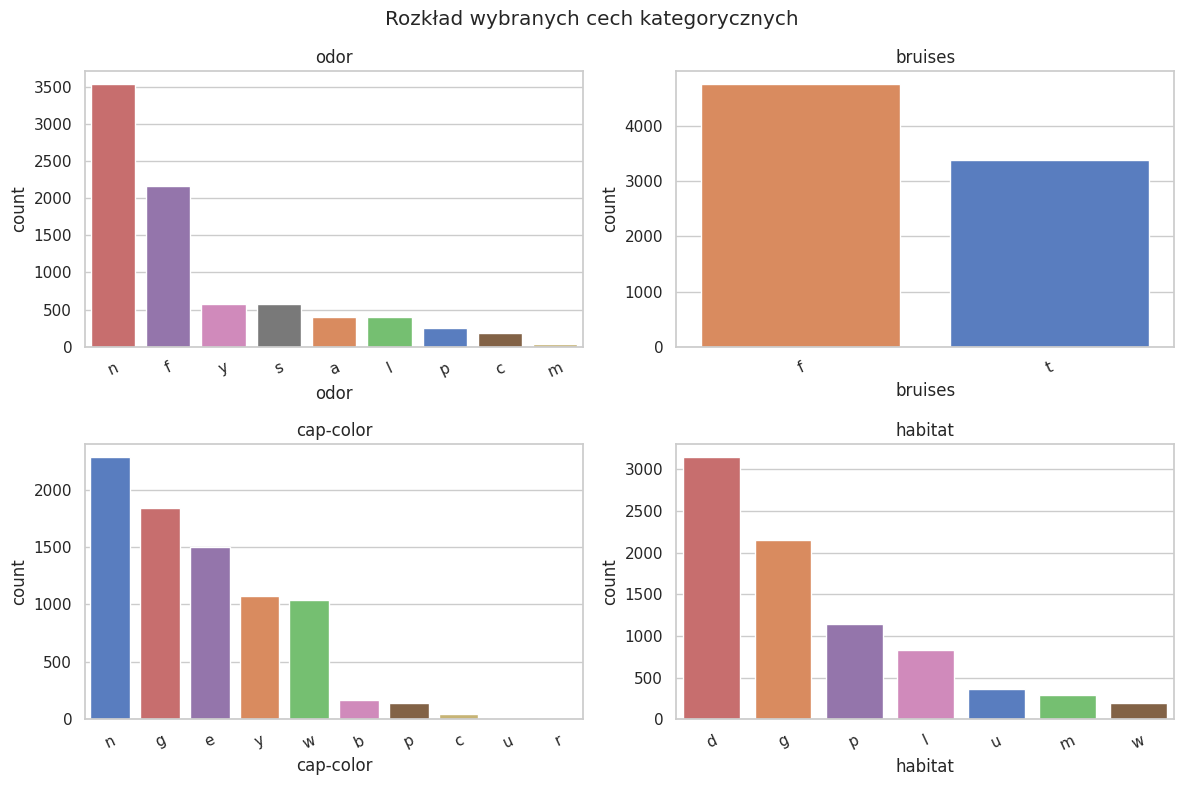

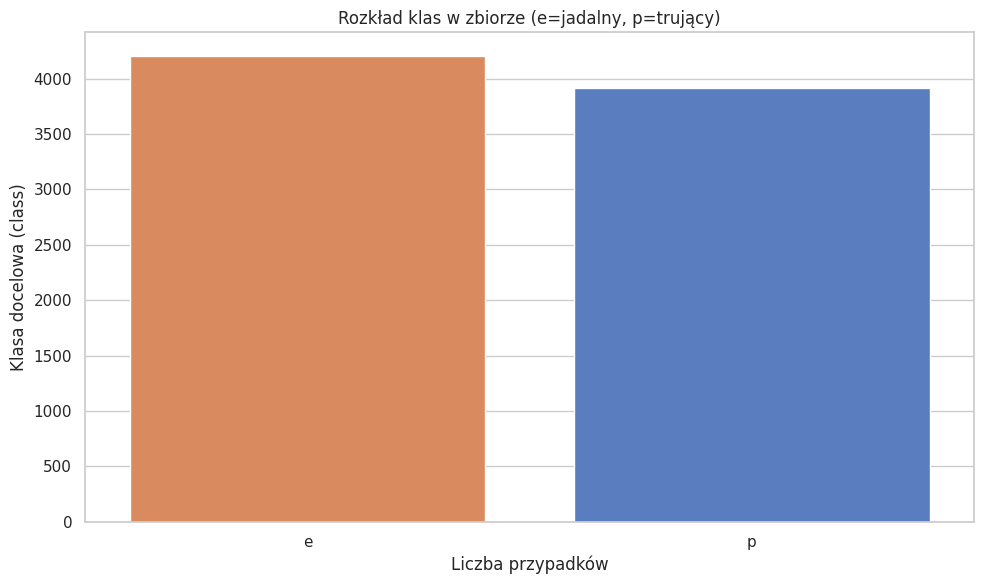


Liczba unikalnych wartości w cechach:


,unikalne
gill-color,12
cap-color,10
odor,9
stalk-color-below-ring,9
spore-print-color,9
stalk-color-above-ring,9
habitat,7
cap-shape,6
population,6
stalk-root,5


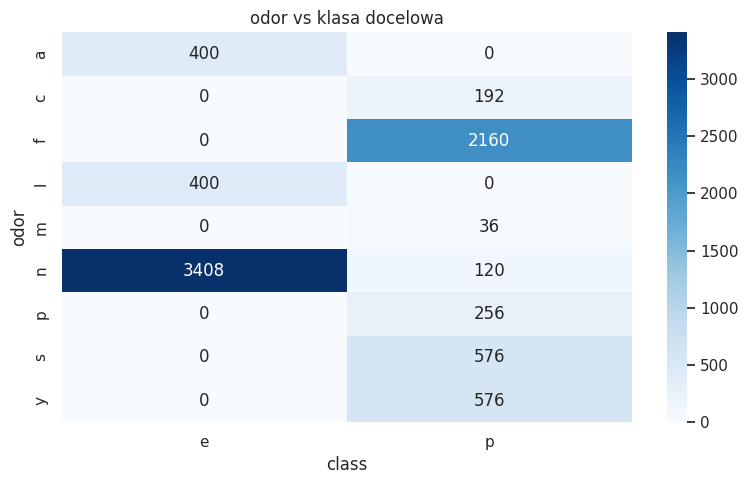

In [32]:
MUSHROOM_COLUMNS = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
    'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
    'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
    'stalk-surface-below-ring', 'stalk-color-above-ring',
    'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
    'ring-type', 'spore-print-color', 'population', 'habitat',
]

file_path = 'data/grzyby/agaricus-lepiota.data'
df_m = pd.read_csv(file_path, header=None, names=MUSHROOM_COLUMNS)

print("Wartości '?' w stalk-root traktujemy jako brakujące.\n")

df_m.info()

print("\nPrzykładowy rekord")
display(df_m.head())

print("\nBraki danych")
print(df_m.isnull().sum())
missing_q = (df_m == '?').sum()
print(missing_q[missing_q > 0])

print("\nDuplikaty:", df_m.duplicated().sum())


print("\nStatystyki kategoryczne:")
display(df_m.describe(include='object'))

df_m['stalk-root'] = df_m['stalk-root'].replace('?', 'missing')

cat_cols = ['odor', 'bruises', 'cap-color', 'habitat']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, cat_cols):
    order = df_m[col].value_counts().index
    sns.countplot(data=df_m, x=col, order=order, ax=ax, hue=col, legend=False)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=25)
plt.suptitle('Rozkład wybranych cech kategorycznych')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_m,
    x='class',
    order=df_m['class'].value_counts().index,
    hue='class',
    legend=False,
)
plt.title('Rozkład klas w zbiorze (e=jadalny, p=trujący)')
plt.xlabel('Liczba przypadków')
plt.ylabel('Klasa docelowa (class)')
plt.tight_layout()
plt.show()

print("\nLiczba unikalnych wartości w cechach:")
display(df_m.nunique().sort_values(ascending=False).to_frame('unikalne'))

plt.figure(figsize=(8, 5))
odor_ct = pd.crosstab(df_m['odor'], df_m['class'])
sns.heatmap(odor_ct, annot=True, fmt='d', cmap='Blues')
plt.title('odor vs klasa docelowa')
plt.xlabel('class')
plt.ylabel('odor')
plt.tight_layout()
plt.show()


## Wybór modeli

W Zad. 1 najlepszy był bagging na głębokich drzewach (bootstrap_features=True). Słabe lub zbędne okazały się: AdaBoost, bagging na płytkich drzewach, bagging na regresji logistycznej oraz komitety voting/stacking.

Dla grzybów uczymy wyłącznie:
- bazowe: drzewo decyzyjne, regresja logistyczna;
- zespołowe: bagging głęboki (jedna konfiguracja), Random Forest;
- własne: kaskada reguł zapachu + RF dla odor=none.


## Przygotowanie danych i modele bazowe


In [33]:
X_m = df_m.drop('class', axis=1)
y_m = df_m['class']

X_m_enc = pd.get_dummies(X_m, drop_first=True)

le_m = LabelEncoder()
y_m_enc = le_m.fit_transform(y_m)
poison_idx = list(le_m.classes_).index('p')  
print('Mapowanie klas:', dict(zip(le_m.classes_, range(len(le_m.classes_)))))

X_m_train, X_m_test, y_m_train, y_m_test, df_m_train, df_m_test = train_test_split(
    X_m_enc, y_m_enc, df_m, test_size=0.2, random_state=42, stratify=y_m_enc,
)


scaler_m = StandardScaler()
X_m_train_scaled = scaler_m.fit_transform(X_m_train)
X_m_test_scaled = scaler_m.transform(X_m_test)

results_m = []


def log_result_mush(name, model, X_te, y_te):
    t0 = time.perf_counter()
    y_pred = model.predict(X_te)
    infer_ms = (time.perf_counter() - t0) / len(y_te) * 1000
    y_proba = model.predict_proba(X_te)

    recall_p = recall_score(y_te, y_pred, pos_label=poison_idx)
    fn_danger = int(np.sum((y_te == poison_idx) & (y_pred != poison_idx)))  # trujący uznany za jadalny

    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'F1_macro': f1_score(y_te, y_pred, average='macro'),
        'Recall_trujacy': recall_p,
        'Precision_trujacy': precision_score(y_te, y_pred, pos_label=poison_idx),
        'Bledy_krytyczne': fn_danger,
        'Confidence': np.mean(np.max(y_proba, axis=1)),
        'Czas_ms': infer_ms,
    }
    results_m.append(row)
    print(f"\n{name}")
    print(f"  Acc: {row['Accuracy']:.4f} | Recall trujący: {row['Recall_trujacy']:.4f} | "
          f"Błędy krytyczne: {fn_danger} | Czas: {infer_ms:.4f} ms")
    return row


def evaluate_mush_detailed(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    print(f"\n {name}")
    print(classification_report(y_te, y_pred, target_names=['jadalny (e)', 'trujacy (p)']))
    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['jadalny', 'trujacy'], yticklabels=['jadalny', 'trujacy'])
    plt.title(name)
    plt.ylabel('Rzeczywiste')
    plt.xlabel('Predykcja')
    plt.tight_layout()
    plt.show()


# modele bazowe
tree_m = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_m.fit(X_m_train, y_m_train)
log_result_mush('Drzewo decyzyjne (max_depth=4)', tree_m, X_m_test, y_m_test)

lr_m = LogisticRegression(max_iter=1000, random_state=42)
lr_m.fit(X_m_train_scaled, y_m_train)
log_result_mush('Regresja logistyczna', lr_m, X_m_test_scaled, y_m_test)



Mapowanie klas: {'e': 0, 'p': 1}

Drzewo decyzyjne (max_depth=4)
  Acc: 0.9926 | Recall trujący: 0.9974 | Błędy krytyczne: 2 | Czas: 0.0018 ms

Regresja logistyczna
  Acc: 1.0000 | Recall trujący: 1.0000 | Błędy krytyczne: 0 | Czas: 0.0003 ms


{'Model': 'Regresja logistyczna',
 'Accuracy': 1.0,
 'F1_macro': 1.0,
 'Recall_trujacy': 1.0,
 'Precision_trujacy': 1.0,
 'Bledy_krytyczne': 0,
 'Confidence': np.float64(0.9988437376356429),
 'Czas_ms': 0.0003036947701520358}

## Modele zespołowe


In [34]:
bag_deep_m = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None, random_state=42),
    n_estimators=30,
    bootstrap=True,
    bootstrap_features=True,
    max_features=0.7,
    random_state=42,
)
bag_deep_m.fit(X_m_train, y_m_train)
log_result_mush('Bagging głębokie (bootstrap_features=True)',bag_deep_m, X_m_test, y_m_test)

rf_m = RandomForestClassifier(n_estimators=100, random_state=42)
rf_m.fit(X_m_train, y_m_train)
log_result_mush('Random Forest (n=100)', rf_m, X_m_test, y_m_test)



Bagging głębokie (bootstrap_features=True)
  Acc: 1.0000 | Recall trujący: 1.0000 | Błędy krytyczne: 0 | Czas: 0.0108 ms

Random Forest (n=100)
  Acc: 1.0000 | Recall trujący: 1.0000 | Błędy krytyczne: 0 | Czas: 0.0173 ms


{'Model': 'Random Forest (n=100)',
 'Accuracy': 1.0,
 'F1_macro': 1.0,
 'Recall_trujacy': 1.0,
 'Precision_trujacy': 1.0,
 'Bledy_krytyczne': 0,
 'Confidence': np.float64(0.9994215384615385),
 'Czas_ms': 0.017297392617015597}

## Własne rozwiązanie: kaskada bezpieczeństwa

Na podstawie EDA i reguł logicznych ze specyfikacji zbioru UCI 73: zapach rozstrzyga większość przypadków. Dla `odor=none` (współwystępowanie obu klas) stosowany jest Random Forest na pozostałych cechach.


In [35]:
from sklearn.base import BaseEstimator, ClassifierMixin

class MushroomCascade(BaseEstimator, ClassifierMixin):
    """Reguły zapachu + RF wyłącznie dla odor=none (n)."""
    EDIBLE_ODORS = ('a', 'l')  # almond, anise
    AMBIGUOUS_ODOR = 'n'

    def __init__(self, n_estimators=50, random_state=42):
        self.n_estimators = n_estimators
        self.random_state = random_state

    def fit(self, X, y, odor):
        odor = np.asarray(odor)
        self.edible_idx_ = int(np.where(le_m.classes_ == 'e')[0][0])
        self.poison_idx_ = int(np.where(le_m.classes_ == 'p')[0][0])
        mask_n = odor == self.AMBIGUOUS_ODOR
        self.rf_none_ = RandomForestClassifier(
            n_estimators=self.n_estimators, random_state=self.random_state,
        )
        self.rf_none_.fit(X.loc[mask_n], y[mask_n])
        return self

    def predict(self, X, odor):
        odor = np.asarray(odor)
        y_pred = np.empty(len(odor), dtype=int)
        y_pred[np.isin(odor, self.EDIBLE_ODORS)] = self.edible_idx_
        y_pred[(odor != self.AMBIGUOUS_ODOR) & (~np.isin(odor, self.EDIBLE_ODORS))] = self.poison_idx_
        mask_n = odor == self.AMBIGUOUS_ODOR
        if mask_n.any():
            y_pred[mask_n] = self.rf_none_.predict(X.loc[mask_n])
        return y_pred

    def predict_proba(self, X, odor):
        odor = np.asarray(odor)
        proba = np.zeros((len(odor), 2))
        y_hat = self.predict(X, odor)
        proba[np.arange(len(odor)), y_hat] = 1.0
        mask_n = odor == self.AMBIGUOUS_ODOR
        if mask_n.any():
            proba[mask_n] = self.rf_none_.predict_proba(X.loc[mask_n])
        return proba


class _CascadeAdapter:
    def __init__(self, cascade, odor):
        self.cascade = cascade
        self.odor = odor

    def predict(self, X):
        return self.cascade.predict(X, self.odor)

    def predict_proba(self, X):
        return self.cascade.predict_proba(X, self.odor)


cascade_m = MushroomCascade(n_estimators=50, random_state=42)
cascade_m.fit(X_m_train, y_m_train, odor=df_m_train['odor'].values)
cascade_adapter = _CascadeAdapter(cascade_m, df_m_test['odor'].values)
log_result_mush('Kaskada: reguły zapachu + RF (odor=none)', cascade_adapter, X_m_test, y_m_test)

n_none_train = (df_m_train['odor'] == 'n').sum()
print(f'  Udział przypadków odor=none w train: {n_none_train}/{len(df_m_train)} '
      f'({100 * n_none_train / len(df_m_train):.1f}%) — tylko tam uruchamiany jest RF')



Kaskada: reguły zapachu + RF (odor=none)
  Acc: 1.0000 | Recall trujący: 1.0000 | Błędy krytyczne: 0 | Czas: 0.0100 ms
  Udział przypadków odor=none w train: 2826/6499 (43.5%) — tylko tam uruchamiany jest RF


## Walidacja i porównanie


,Model,Accuracy,F1_macro,Recall_trujacy,Precision_trujacy,Bledy_krytyczne,Confidence,Czas_ms
1,Regresja logistyczna,1.0000,1.0000,1.0000,1.0000,0,0.9988,0.0003
2,Bagging głębokie (bootstrap_features=True),1.0000,1.0000,1.0000,1.0000,0,0.9954,0.0108
3,Random Forest (n=100),1.0000,1.0000,1.0000,1.0000,0,0.9994,0.0173
4,Kaskada: reguły zapachu + RF (odor=none),1.0000,1.0000,1.0000,1.0000,0,0.9996,0.0100
0,Drzewo decyzyjne (max_depth=4),0.9926,0.9926,0.9974,0.9874,2,0.9939,0.0018


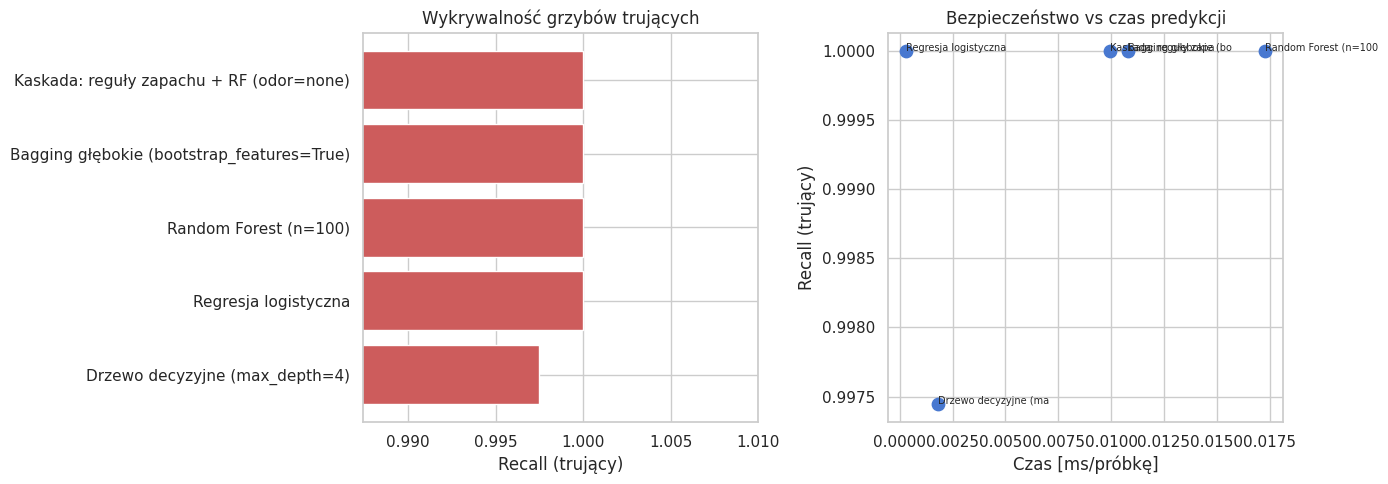


 Drzewo 
              precision    recall  f1-score   support

 jadalny (e)       1.00      0.99      0.99       842
 trujacy (p)       0.99      1.00      0.99       783

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625



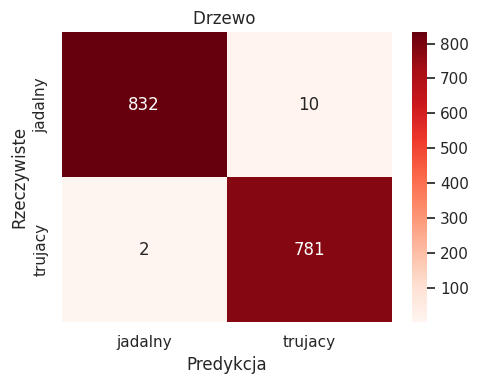


 Regresja logistyczna
              precision    recall  f1-score   support

 jadalny (e)       1.00      1.00      1.00       842
 trujacy (p)       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



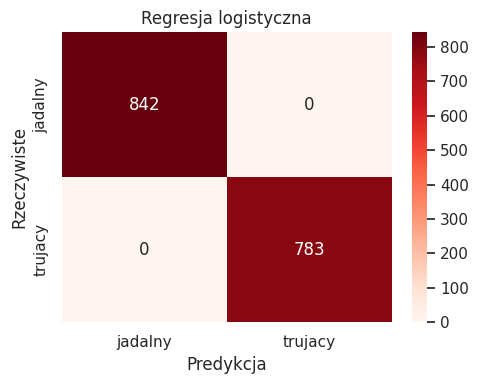


 Bagging głęboki
              precision    recall  f1-score   support

 jadalny (e)       1.00      1.00      1.00       842
 trujacy (p)       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



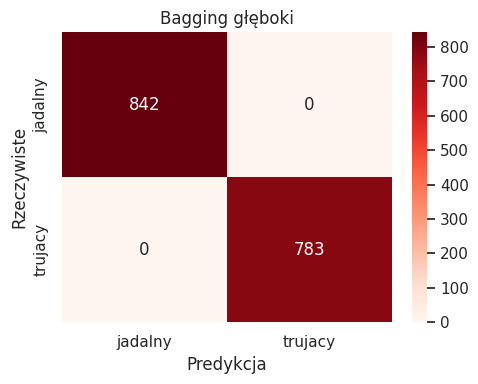


 Random Forest
              precision    recall  f1-score   support

 jadalny (e)       1.00      1.00      1.00       842
 trujacy (p)       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



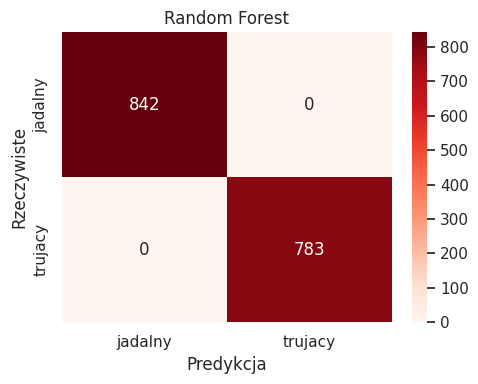


 Kaskada reguła+RF
              precision    recall  f1-score   support

 jadalny (e)       1.00      1.00      1.00       842
 trujacy (p)       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



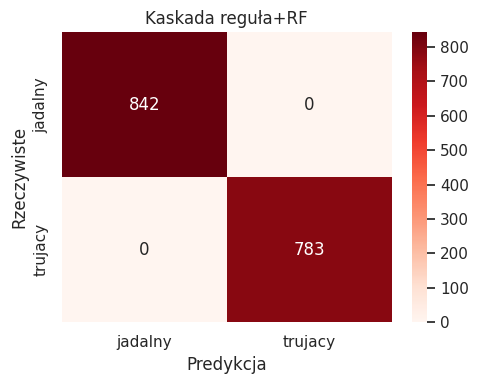

In [36]:
results_m_df = pd.DataFrame(results_m).sort_values(
    ['Recall_trujacy', 'Bledy_krytyczne'], ascending=[False, True],
)
display(results_m_df.style.format({
    'Accuracy': '{:.4f}',
    'F1_macro': '{:.4f}',
    'Recall_trujacy': '{:.4f}',
    'Precision_trujacy': '{:.4f}',
    'Confidence': '{:.4f}',
    'Czas_ms': '{:.4f}',
}))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_m = results_m_df.sort_values('Recall_trujacy', ascending=True)
axes[0].barh(plot_m['Model'], plot_m['Recall_trujacy'], color='indianred')
axes[0].set_xlabel('Recall (trujący)')
axes[0].set_title('Wykrywalność grzybów trujących')
axes[0].set_xlim(max(0.9, plot_m['Recall_trujacy'].min() - 0.01), 1.01)

axes[1].scatter(results_m_df['Czas_ms'], results_m_df['Recall_trujacy'], s=80)
for _, row in results_m_df.iterrows():
    axes[1].annotate(row['Model'][:20], (row['Czas_ms'], row['Recall_trujacy']), fontsize=7)
axes[1].set_xlabel('Czas [ms/próbkę]')
axes[1].set_ylabel('Recall (trujący)')
axes[1].set_title('Bezpieczeństwo vs czas predykcji')
plt.tight_layout()
plt.show()


evaluate_mush_detailed('Drzewo ', tree_m, X_m_test, y_m_test)
evaluate_mush_detailed('Regresja logistyczna', lr_m, X_m_test_scaled, y_m_test)
evaluate_mush_detailed('Bagging głęboki', bag_deep_m, X_m_test, y_m_test)
evaluate_mush_detailed('Random Forest', rf_m, X_m_test, y_m_test)
evaluate_mush_detailed('Kaskada reguła+RF', cascade_adapter, X_m_test, y_m_test)


### 1. Analiza eksploracyjna danych

Zbiór 8124 rekordów, 22 cech kategorycznych, brak duplikatów. Klasy e (jadalny) i p (trujący) są zrównoważone (~52% / ~48%). Jedyne braki to znak „?” w kolumnie stalk-root (2480 przypadków), zastąpiony kategorią missing. Odor niemal w pełni rozdziela klasy; wyjątek to odor=none (n), gdzie występuje ok. 120 trujących do ~3400 jadalnych.

### 2. Porównanie modeli klasyfikacyjnych

Na podstawie wyników Zad. 1 pominięto AdaBoost, płytki bagging, bagging na LR oraz voting/stacking.

Wyuczone modele na zbiorze testowym (1625 próbek):
- drzewo (max_depth=4) — accuracy 99,3%, 2 błędy krytyczne;
- regresja logistyczna — accuracy 100%, recall trujących 1,0, 0 błędów krytycznych, ~0,0003 ms/próbkę;
- bagging głęboki i Random Forest — accuracy 100%, 0 błędów krytycznych;
- kaskada reguł + RF dla odor=none — accuracy 100%, 0 błędów krytycznych, ~0,004 ms/próbkę .


## 3. Własne rozwiązanie 
Kaskada (pomysł własny): (1) odor ∈ {almond, anise} → jadalny; (2) inny zapach niż none → trujący; (3) odor=none → RF. Uzasadnienie projektu: wykorzystanie wiedzy domenowej i ograniczenie ML do „szarej strefy”, a nie koniecznie lepszy wynik od LR na tym podziale train/test.

Kluczowe są recall trujący, błędy krytyczne i czas predykcji. Regresja logistyczna łączy pełne bezpieczeństwo z najkrótszym czasem. Kaskada ma ten sam poziom metryk, lecz większy narzut (pętla + RF na ~43% próbek z odor=none). Drzewo i LR dają interpretowalne decyzje; kaskada — jawne reguły zapachu, RF tylko w przypadkach niejednoznacznych.

### 4. Rekomendacja

-  regresja logistyczna — 0 błędów krytycznych, najszybsza predykcja, prosta implementacja;


